# ==============================================================

[*********************100%***********************]  4 of 4 completed


---- Annualized Returns ----
Ticker
FIZZ     0.121043
NPK      0.133829
VLGEA    0.078451
WEYS     0.083320
dtype: float64
---- Annualized Variance ----
Ticker
FIZZ     0.152009
NPK      0.079314
VLGEA    0.085255
WEYS     0.145925
dtype: float64
---- Annualized Standard Deviation ----
Ticker
FIZZ     0.389883
NPK      0.281628
VLGEA    0.291984
WEYS     0.382001
dtype: float64
---- Covariance Matrix ----
Ticker      FIZZ       NPK     VLGEA      WEYS
Ticker                                        
FIZZ    0.152009  0.016200  0.019251  0.021204
NPK     0.016200  0.079314  0.021217  0.032485
VLGEA   0.019251  0.021217  0.085255  0.032158
WEYS    0.021204  0.032485  0.032158  0.145925
---- Correlation Matrix ----
Ticker      FIZZ       NPK     VLGEA      WEYS
Ticker                                        
FIZZ    1.000000  0.147539  0.169108  0.142371
NPK     0.147539  1.000000  0.258021  0.301957
VLGEA   0.169108  0.258021  1.000000  0.288311
WEYS    0.142371  0.301957  0.288311  1.00000

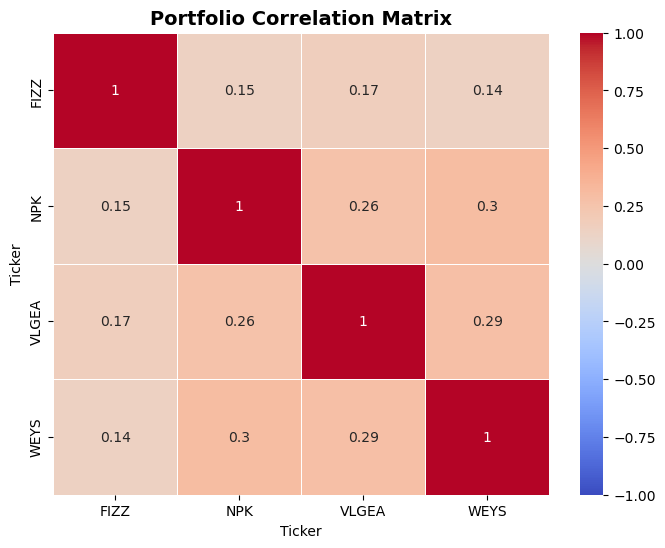

--- Portfolio Variance ---
0.046720839645929726
--- Portfolio Volatility ---
0.2161500396621054
--- Weighted Average Volatility (No Diversification) ---
0.3363740166394117
--- Diversification Benefit (Risk Saved) ---
0.1202239769773063
--- Own-Variance (Diversifiable) % ---
61.870482041754826
--- Cross-Variance (Systematic) % ---
38.129517958245174
--- Generating Rolling Volatility Plot ---


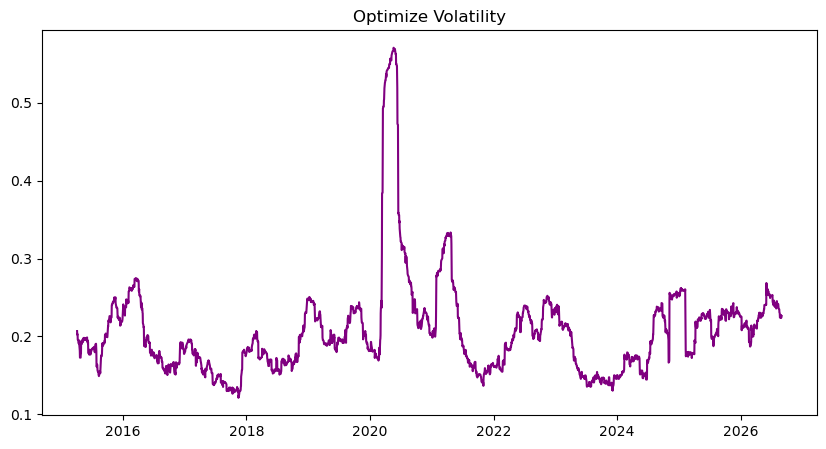

In [1]:
# Imports
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import datetime
import matplotlib.ticker as mtick
import seaborn as sns

# Constants
TICKERS      = ["NPK", "VLGEA", "WEYS", "FIZZ"]
START_DATE   = "2015-01-01" 
END_DATE     = "2026-09-01" 
TRADING_DAYS = 252
weights = pd.Series({
    "NPK":0.25,
    "VLGEA":0.25,
    "WEYS":0.25,
    "FIZZ":0.25
})

# DATA
def get_market_data(tickers, start_date, end_date):
    data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)["Close"]
    data = data.dropna()
    assert data.index.is_monotonic_increasing, "Data Error: Index is not sorted."
    assert data.isna().sum().sum() == 0, "Data Error: NaNs detected."
    return data

# LOG RETURN
def compute_returns(data):
    log_return = np.log(data / data.shift(1)).dropna()
    return log_return

# ANNUAL RETURN
def compute_annual_return(log_return):
    annual_return = log_return.mean() * TRADING_DAYS
    return annual_return

# VARIANCE & STANDARD DEVIATION
def compute_volatility(log_return):
    variance = log_return.var() * TRADING_DAYS
    annual_standard_deviation = log_return.std() * np.sqrt(TRADING_DAYS)
    return variance, annual_standard_deviation

# COVARIANCE MATRIX
def compute_covariance_matrix(log_return):
    covariance_matrix = log_return.cov() * TRADING_DAYS
    return covariance_matrix

# CORRELATION MATRIX
def compute_correlation_matrix(log_return):
    correlation_matrix = log_return.corr()
    return correlation_matrix

# CORRELATION HEATMAP
def plot_correlation_heatmap(correlation_matrix):
    plt.figure(figsize=(8,6))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
    plt.title("Portfolio Correlation Matrix", fontsize=14, fontweight="bold")
    plt.show()

# Portfolio Risk 
def compute_portfolio_risk(cov_matrix, weights):
    portfolio_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
    portfolio_volatility = np.sqrt(portfolio_variance)
    return portfolio_variance, portfolio_volatility

# Diversification Proof
def compute_diversification_benefit(weights, annual_volatility, portfolio_volatility):
    weights_average_volatility = (weights * annual_volatility).sum()
    diversification_benefit = weights_average_volatility - portfolio_volatility
    return weights_average_volatility, diversification_benefit

# Systematic vs Unsystematic Risk Breakdown
def compute_risk_breakdown(weights, variance, portfolio_variance):
    own_variance = (weights ** 2 * variance).sum()
    cross_variance = portfolio_variance - own_variance
    own_pct = own_variance / portfolio_variance
    cross_pct = cross_variance / portfolio_variance
    
    return own_variance, cross_variance, own_pct, cross_pct

# Rolling Volatility
def compute_rolling_volatility(log_return, weights, window=63):
    portfolio_returns = (log_return * weights).sum(axis = 1) 
    rolling_vol = portfolio_returns.rolling(window=window).std() * np.sqrt(TRADING_DAYS)
    return rolling_vol
def plot_rolling_volatility(rolling_vol):
    plt.figure(figsize=(10,5))
    plt.plot(rolling_vol, color="purple", label="63-Day Rolling Volatility")
    plt.title("Optimize Volatility")
    plt.show()
    
# MAIN BLOCK
if __name__ == "__main__":
    # 1. Fetch Data
    data = get_market_data(TICKERS, START_DATE, END_DATE)
    
    # 2. Compute Returns
    log_return = compute_returns(data)
    
    # 3. Compute Risk Profile
    annual_return = compute_annual_return(log_return)
    variance, annual_volatility = compute_volatility(log_return)
    
    # 4. Print Results
    print("---- Annualized Returns ----")
    print(annual_return)
    print("---- Annualized Variance ----")
    print(variance)
    print("---- Annualized Standard Deviation ----")
    print(annual_volatility)
    
    # 5. Covariance & Correlation
    cov_matrix = compute_covariance_matrix(log_return)
    corr_matrix = compute_correlation_matrix(log_return)
    
    print("---- Covariance Matrix ----")
    print(cov_matrix)
    print("---- Correlation Matrix ----")
    print(corr_matrix)
    
    # 6. Plot Heatmap
    plot_correlation_heatmap(corr_matrix)
    
    # 7. Weights
    weights = pd.Series({
        "NPK":0.25,
        "VLGEA":0.25,
        "WEYS":0.25,
        "FIZZ":0.25
    })
    portfolio_variance, portfolio_volatility = compute_portfolio_risk(cov_matrix, weights)
    
    print("--- Portfolio Variance ---")
    print(portfolio_variance)
    print("--- Portfolio Volatility ---")
    print(portfolio_volatility)
    
    # 8. Diversification Benefit
    weighted_avg_vol, div_benefit = compute_diversification_benefit(weights, annual_volatility, portfolio_volatility)
    
    print("--- Weighted Average Volatility (No Diversification) ---")
    print(weighted_avg_vol)
    print("--- Diversification Benefit (Risk Saved) ---")
    print(div_benefit)
    
    # 9. Systematic vs Unsystematic Risk
    own_variance, cross_variance, own_pct, cross_pct = compute_risk_breakdown(weights, variance, portfolio_variance)
    
    print("--- Own-Variance (Diversifiable) % ---")
    print(own_pct * 100)
    print("--- Cross-Variance (Systematic) % ---")
    print(cross_pct * 100)
    
    # 10. Rolling Volatility
    rolling_vol = compute_rolling_volatility(log_return, weights)
    
    print("--- Generating Rolling Volatility Plot ---")
    plot_rolling_volatility(rolling_vol)

# ==============================================================